In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

dir_path = "../data"
control_dir = os.path.join(dir_path, "TERBINAFINE- (control)")
terbinafine_dir = os.path.join(dir_path, "TERBINAFINE+")

***
# Statistical analysis of the dataset

## Dataset formation
This analysis is performed on the **training set**, using the experiments of 2024/08/27, 2024/09/24, 2025/02/05, 2025/03/18 and 2025/04/15.

In [2]:
summary = {
    "id": [],
    "filepath": [],
    "lifespan_frames": [],
    "terbinafine": [],
    "experiment": []
}
dataframes = {}

for filename in os.listdir(control_dir):
    if filename.endswith(".csv"):
        filepath = os.path.join(control_dir, filename)
        id = str(filename.split("_")[3:5])
        experiment = str(filename.split("_")[2])
        df = pd.read_csv(filepath)
        dataframes[id] = df
        summary["id"].append(id)
        summary["filepath"].append(filepath)
        summary["lifespan_frames"].append(len(df))
        summary["terbinafine"].append(False)
        summary["experiment"].append(experiment)



for filename in os.listdir(terbinafine_dir):
    if filename.endswith(".csv"):
        filepath = os.path.join(terbinafine_dir, filename)
        id = str(filename.split("_")[3:5])
        experiment = str(filename.split("_")[2])
        df = pd.read_csv(filepath)
        dataframes[id] = df
        summary["id"].append(id)
        summary["filepath"].append(filepath)
        summary["lifespan_frames"].append(len(df))
        summary["terbinafine"].append(True)
        summary["experiment"].append(experiment)

summary_df = pd.DataFrame(summary, columns=["id", "filepath", "experiment", "lifespan_frames", "terbinafine"])
display(summary_df.head())

,id,filepath,experiment,lifespan_frames,terbinafine
0,"['10', '1']",../data\TERBINAFINE- (control)\coordinates_hig...,20240827,51301,False
1,"['10', '5']",../data\TERBINAFINE- (control)\coordinates_hig...,20240827,54901,False
2,"['12', '3']",../data\TERBINAFINE- (control)\coordinates_hig...,20240827,64800,False
3,"['12', '4']",../data\TERBINAFINE- (control)\coordinates_hig...,20240827,64800,False
4,"['10', '1']",../data\TERBINAFINE- (control)\coordinates_hig...,20240924,51301,False


## Basic statistics

In [3]:
display("Terbinafine True:")
display(summary_df[summary_df["terbinafine"] == True]["lifespan_frames"].describe())
display("---------------------------------")
display("Terbinafine False:")
display(summary_df[summary_df["terbinafine"] == False]["lifespan_frames"].describe())

'Terbinafine True:'

count        49.000000
mean      75600.244898
std       20270.640411
min       41401.000000
25%       63001.000000
50%       70200.000000
75%       82800.000000
max      129600.000000
Name: lifespan_frames, dtype: float64

'---------------------------------'

'Terbinafine False:'

count        43.000000
mean      71749.139535
std       16747.961059
min       46801.000000
25%       59401.000000
50%       69300.000000
75%       76950.000000
max      123300.000000
Name: lifespan_frames, dtype: float64

## Distribution Plots 

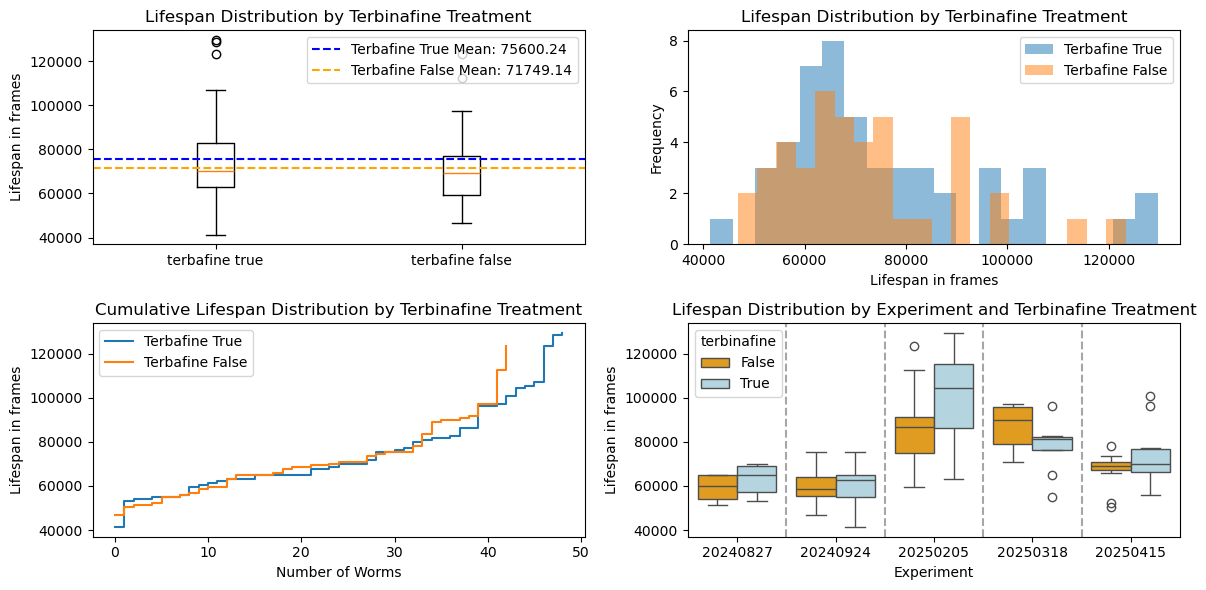

In [4]:
import seaborn as sns

lifespan = {
    'terbafine true': summary_df[summary_df["terbinafine"] == True]['lifespan_frames'],
    'terbafine false': summary_df[summary_df["terbinafine"] == False]['lifespan_frames']
}

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 6))

# boxplot
ax1.boxplot(lifespan.values(), tick_labels=lifespan.keys())
ax1.set_title('Lifespan Distribution by Terbinafine Treatment')
ax1.set_ylabel('Lifespan in frames')
# mean of both groups
mean_true = lifespan['terbafine true'].mean()
mean_false = lifespan['terbafine false'].mean()
ax1.axhline(mean_true, color='blue', linestyle='--', label=f'Terbafine True Mean: {mean_true:.2f}')
ax1.axhline(mean_false, color='orange', linestyle='--', label=f'Terbafine False Mean: {mean_false:.2f}')
ax1.legend()


# distribution histogram
ax2.hist(lifespan['terbafine true'], bins=20, alpha=0.5, label='Terbafine True')
ax2.hist(lifespan['terbafine false'], bins=20, alpha=0.5, label='Terbafine False')
ax2.set_title('Lifespan Distribution by Terbinafine Treatment')
ax2.set_xlabel('Lifespan in frames')
ax2.set_ylabel('Frequency')
ax2.legend()

# cumulative distribution
lifespan['terbafine true'].sort_values().reset_index(drop=True).plot(ax=ax3, label='Terbafine True', drawstyle='steps-post')
lifespan['terbafine false'].sort_values().reset_index(drop=True).plot(ax=ax3, label='Terbafine False', drawstyle='steps-post')
ax3.set_title('Cumulative Lifespan Distribution by Terbinafine Treatment')
ax3.set_xlabel('Number of Worms')
ax3.set_ylabel('Lifespan in frames')
ax3.legend()

# per experiment & per treatment boxplot
sns.boxplot(
    data=summary_df, 
    x='experiment', 
    y='lifespan_frames', 
    hue='terbinafine', 
    palette={False: 'orange', True: 'lightblue'}, 
    ax=ax4
)
ax4.set_title('Lifespan Distribution by Experiment and Terbinafine Treatment')
ax4.set_xlabel('Experiment')
ax4.set_ylabel('Lifespan in frames')

# Add vertical lines between experiments
for i in range(1, summary_df['experiment'].nunique()):
    ax4.axvline(i - 0.5, color='gray', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Statistical tests

### Test on the whole dataset
On the two groups, to try to statistically show that the distribution of the lifespan is different between the worms drugged vs non-drugged

In [5]:
# statistics
print("Terbinafine True Lifespan Stats:")
print(lifespan['terbafine true'].describe())
print("\nTerbinafine False Lifespan Stats:")
print(lifespan['terbafine false'].describe())


# Kolmogorov-Smirnov test between the two groups
from scipy.stats import ks_2samp
stat, p = ks_2samp(lifespan['terbafine true'], lifespan['terbafine false'])
print(f"\nKS 2-sample Test: statistic={stat}, p-value={p}")

# Mann-Whitney U test between the two groups
from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(lifespan['terbafine true'], lifespan['terbafine false'])
print(f"\nMann-Whitney U Test: U={stat}, p-value={p}")


# Classic T test
from scipy.stats import ttest_ind
stat, p = ttest_ind(lifespan['terbafine true'], lifespan['terbafine false'], equal_var=False)
print(f"\nT-Test: t={stat}, p-value={p}")

Terbinafine True Lifespan Stats:
count        49.000000
mean      75600.244898
std       20270.640411
min       41401.000000
25%       63001.000000
50%       70200.000000
75%       82800.000000
max      129600.000000
Name: lifespan_frames, dtype: float64

Terbinafine False Lifespan Stats:
count        43.000000
mean      71749.139535
std       16747.961059
min       46801.000000
25%       59401.000000
50%       69300.000000
75%       76950.000000
max      123300.000000
Name: lifespan_frames, dtype: float64

KS 2-sample Test: statistic=0.13194114855244424, p-value=0.7566524292817465

Mann-Whitney U Test: U=1136.0, p-value=0.5207091638828107

T-Test: t=0.9973874094788139, p-value=0.32125967380726655


**Interpretation:**  
This is the result without knowledge of the discrepency introduced by the experiments. 

*For recall*, the p value is roughly the probability that the observations are sampled from the null hypothesis distribution. In our case, the null hypothesis is that the two distribution are the same. *More exactly, the p value is the probability of sampling results at least as extreme as the observations we have, under the null hypothesis. Thus, a very low p value indicates that the observations are not due to chance.*

Those p values indicate that we cannot reject the null hypothesis (p values above the standard alpha level at 0.05), at least we cannot reject it with confidence more than 50% (using the generalistic Mann-Whitney U test).

### Per experiment tests

In [6]:
for experiment in summary_df['experiment'].unique():
    true_lifespan = summary_df[(summary_df['experiment'] == experiment) & (summary_df['terbinafine'] == True)]['lifespan_frames']
    false_lifespan = summary_df[(summary_df['experiment'] == experiment) & (summary_df['terbinafine'] == False)]['lifespan_frames']
    ks, p_ks = ks_2samp(true_lifespan, false_lifespan)
    stat, p = mannwhitneyu(true_lifespan, false_lifespan)
    t, p_t = ttest_ind(true_lifespan, false_lifespan)
    print(f"Experiment {experiment} KS 2-sample Test: statistic={ks}, p-value={p_ks}")
    print(f"Experiment {experiment} Mann-Whitney U Test: U={stat}, p-value={p}")
    print(f"Experiment {experiment} T test: T={t}, p value={p_t}")
    print()

Experiment 20240827 KS 2-sample Test: statistic=0.42857142857142855, p-value=0.6606060606060606
Experiment 20240827 Mann-Whitney U Test: U=19.0, p-value=0.3896502359426921
Experiment 20240827 T test: T=0.8783132564772332, p value=0.40261273998545666

Experiment 20240924 KS 2-sample Test: statistic=0.30303030303030304, p-value=0.5559901129964396
Experiment 20240924 Mann-Whitney U Test: U=74.5, p-value=0.6208165828332859
Experiment 20240924 T test: T=0.5647010010472865, p value=0.5782600205023432

Experiment 20250205 KS 2-sample Test: statistic=0.43636363636363634, p-value=0.19552841379466765
Experiment 20250205 Mann-Whitney U Test: U=73.5, p-value=0.20452730761920823
Experiment 20250205 T test: T=1.3501790393048005, p value=0.19282411485680748

Experiment 20250318 KS 2-sample Test: statistic=0.5416666666666666, p-value=0.19247419247419248
Experiment 20250318 Mann-Whitney U Test: U=14.0, p-value=0.2190158983170909
Experiment 20250318 T test: T=-1.3745830308772253, p value=0.1943862415043

**Interpretation:**  
Since the experiments are independant, we can also test every experiment it self and draw conclusion from all the results.  

Here we can observe that 3 experiments have lower T-test p-values (test assuming that the data are normally distributed), under 0.2. While not meeting the standard of 0.05.

### Mixed linear model

Here I used a Mixed Linear Model. This is a regression model accounting for different groups (for us, the experiments) by trying to fit the equation: $Y_{ij} = \beta_0 + \beta_1 X_{ij} + u_i + \epsilon_{ij}$, with:

- $Y_{ij​}$ : Lifespan of sample $j$ in experiment $i$ (the observation).
- $X_{ij​}$ : Indicator variable for drugged or non-drugged.
- $u_i​$ : Random effect of experiment $i$, $u_i​∼N(0,\hat{\sigma}^2_{u​})$, $\hat{\sigma}^2_{u​}$ the Group Var, i.e the between group variance.
- $\epsilon_{ij}$ : Random noise, $\epsilon_{ij}​∼N(0,\hat{\sigma}^2_{\epsilon})$, $\hat{\sigma}^2_{\epsilon}$ the Scale, i.e the within group variance.  

The idea is to fit the model on the observations, and interpret the value $\beta_1$ which despicts directly the effect of the terbinafine.
This model is roughly suited for small datasets because of its simplicity, and greatly takes into account the different groups.

In [7]:
import statsmodels.formula.api as smf

model = smf.mixedlm("lifespan_frames ~ terbinafine", summary_df, groups=summary_df["experiment"])

results = model.fit()
print(results.summary())

                   Mixed Linear Model Regression Results
Model:                 MixedLM      Dependent Variable:      lifespan_frames
No. Observations:      92           Method:                  REML           
No. Groups:            5            Scale:                   187601905.2008 
Min. group size:       11           Log-Likelihood:          -994.6547      
Max. group size:       23           Converged:               Yes            
Mean group size:       18.4                                                 
----------------------------------------------------------------------------
                        Coef.      Std.Err.   z    P>|z|   [0.025    0.975] 
----------------------------------------------------------------------------
Intercept               71288.116  6573.579 10.845 0.000 58404.137 84172.095
terbinafine[T.True]      4101.270  2874.652  1.427 0.154 -1532.944  9735.484
Group Var           192678423.128 10731.501                                 



**Interpretation of the result:**  
1) *Fixed effect of the drug:* The line to look at is the line `terbinafine[T.True]`.  
First, the p value of the Wald test (column `P>|z|`) is still higher than the 0.05 standard *(consistent with what we have seen so far)*.  
Moreover, the confidence interval at 95% crosses the 0 line (values ranging from -1532 to 9735), meaning that the terbinafine had a negative effect on the lifespan, inside the 95% confidence interval.  
With that being said, the coefficient is still positive, with the majority of the interval lying in the positive region as well. This can indicate that we simply don't have enough data to statistically confirm the effect, while it is there.

2) *Random effect:* The Scale (variance within the groups) and the Group Var (variance between the experiments) are very similar (ratio $\frac{187601905}{192678423} ~= 0.97$) meaning that the majority of the variance observe within a group can be driven by systematic difference between the experiments (which can be from unobserves natural causes).


**My interpretation**  
From my data science perspective, it is too soon to conclude for the positive effect of terbinafine on the C. Elegans lifespan, since none of the statistical tests reached this conclusion. But this can totally be explained by the lack of data: 100 samples is really really low.   
From the plots, the per-experiment lower p values and the coefficent of the mixed model: we can guess (almost see) a positive effect, while not being able to statistically confirm it. 